# Notebook 04b — Hyperparameter-Suche auf dem Scratch-CNN

**Ziel:** Systematisches Testen von **Lernrate × Dropout** auf dem Scratch-CNN.

**Grid:** 3 × 3 = 9 Konfigurationen

| Hyperparameter | Werte |
|---|---|
| Learning Rate | `1e-2`, `1e-3`, `1e-4` |
| Dropout (vor FC) | `0.3`, `0.5`, `0.7` |

Pro Konfiguration: 15 Epochs (verkürzt — genug um relative Unterschiede zu sehen).
Gespeichert wird **keine Modell-Checkpoint**, nur die komplette Loss/Acc-History  
→ ermöglicht Analyse von Konvergenzgeschwindigkeit und Train/Val-Gap.

**Divergenz-Behandlung:** LR=1e-2 kann divergieren (NaN-Loss oder Explosion).  
Solche Runs werden als `diverged=True` markiert und übersprungen — das ist
selbst aufschlussreiches Material für die Diskussion.

In [1]:
import math
import random
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from dataset import AlbumCoverDataset, compute_class_weights  # noqa: E402

SPLITS_DIR = ROOT / "data" / "splits"

# ── Reproduzierbarkeit ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = (
    torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


## Hyperparameter-Grid

In [2]:
LR_VALUES      = [1e-2, 1e-3, 1e-4]
DROPOUT_VALUES = [0.3,  0.5,  0.7]
HP_EPOCHS      = 15
BATCH_SIZE     = 32

print(f"Grid: {len(LR_VALUES)} LRs × {len(DROPOUT_VALUES)} Dropouts = {len(LR_VALUES)*len(DROPOUT_VALUES)} Runs")
print(f"Epochs pro Run: {HP_EPOCHS}")

Grid: 3 LRs × 3 Dropouts = 9 Runs
Epochs pro Run: 15


## DataLoaders

In [3]:
pin         = device.type == "cuda"   # pin_memory nur sinnvoll bei CUDA
num_workers = 0                        # 0 = sicher in Notebooks auf macOS (MPS/fork quirks)

train_loader = DataLoader(
    AlbumCoverDataset(SPLITS_DIR / "train.csv", "train"),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin,
)
val_loader = DataLoader(
    AlbumCoverDataset(SPLITS_DIR / "val.csv", "val"),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin,
)

class_weights = compute_class_weights(SPLITS_DIR / "train.csv").to(device)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 56, Val batches: 12


## CNN-Architektur (identisch zu Notebook 04)

In [4]:
class ScratchCNN(nn.Module):
    """Vier Conv-Blöcke + Global Average Pooling + FC(256, 10).

    Dropout-Wahrscheinlichkeit p ist parametrisierbar für den HP-Sweep.
    """

    def __init__(self, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 → 32, 224→112
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 2: 32 → 64, 112→56
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 3: 64 → 128, 56→28
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 4: 128 → 256, 28→GAP
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # type: ignore[override]
        return self.classifier(self.features(x))

## Probe-Training-Funktion

In [5]:
DIVERGE_NAN_THRESHOLD = 10.0  # Loss-Vielfaches des Startwerts ab Epoch 3


def train_probe(
    lr: float,
    dropout: float,
    epochs: int = HP_EPOCHS,
) -> dict:
    """Trainiert ein ScratchCNN für *epochs* Epochs und gibt die komplette History zurück."""
    # Seed für jeden Run neu setzen → reproduzierbare Initialisierung
    torch.manual_seed(SEED)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(SEED)

    model = ScratchCNN(dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history: dict = {
        "best_val_acc":    0.0,
        "train_loss_hist": [],
        "val_loss_hist":   [],
        "train_acc_hist":  [],
        "val_acc_hist":    [],
        "diverged":        False,
    }

    initial_loss: float | None = None

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * len(labels)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += len(labels)

        train_loss = t_loss / t_total
        train_acc  = t_correct / t_total

        # ── Divergenz-Check ──
        if math.isnan(train_loss) or math.isinf(train_loss):
            print(f"  → Divergiert (NaN/Inf) in Epoch {epoch}")
            history["diverged"] = True
            break
        if initial_loss is None:
            initial_loss = train_loss
        elif epoch >= 3 and train_loss > DIVERGE_NAN_THRESHOLD * initial_loss:
            print(f"  → Divergiert (Loss {train_loss:.2f} > {DIVERGE_NAN_THRESHOLD}× initial {initial_loss:.2f}) in Epoch {epoch}")
            history["diverged"] = True
            break

        # ── Val ──
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * len(labels)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += len(labels)

        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total

        history["train_loss_hist"].append(train_loss)
        history["val_loss_hist"].append(val_loss)
        history["train_acc_hist"].append(train_acc)
        history["val_acc_hist"].append(val_acc)
        history["best_val_acc"] = max(history["best_val_acc"], val_acc)

    return history

## Grid-Sweep ausführen

In [6]:
results: dict[tuple[float, float], dict] = {}
total_runs = len(LR_VALUES) * len(DROPOUT_VALUES)

for run_idx, (lr, dropout) in enumerate(product(LR_VALUES, DROPOUT_VALUES), start=1):
    print(f"[{run_idx:2d}/{total_runs}] lr={lr:.0e}  dropout={dropout:.1f} ...", end="  ", flush=True)
    t0 = time.time()
    try:
        history = train_probe(lr=lr, dropout=dropout)
    except Exception as exc:  # noqa: BLE001
        print(f"FEHLER: {exc}")
        history = {
            "best_val_acc":    0.0,
            "train_loss_hist": [],
            "val_loss_hist":   [],
            "train_acc_hist":  [],
            "val_acc_hist":    [],
            "diverged":        True,
        }
    elapsed = time.time() - t0
    status = "DIVERGIERT" if history["diverged"] else f"best_val_acc={history['best_val_acc']:.3f}"
    print(f"{status}  ({elapsed:.0f}s)")
    results[(lr, dropout)] = history

print("\nAlle Runs abgeschlossen.")

[ 1/9] lr=1e-02  dropout=0.3 ...  best_val_acc=0.184  (263s)
[ 2/9] lr=1e-02  dropout=0.5 ...  best_val_acc=0.217  (326s)
[ 3/9] lr=1e-02  dropout=0.7 ...  best_val_acc=0.184  (478s)
[ 4/9] lr=1e-03  dropout=0.3 ...  best_val_acc=0.248  (477s)
[ 5/9] lr=1e-03  dropout=0.5 ...  best_val_acc=0.223  (508s)
[ 6/9] lr=1e-03  dropout=0.7 ...  best_val_acc=0.231  (438s)
[ 7/9] lr=1e-04  dropout=0.3 ...  best_val_acc=0.226  (453s)
[ 8/9] lr=1e-04  dropout=0.5 ...  best_val_acc=0.253  (532s)
[ 9/9] lr=1e-04  dropout=0.7 ...  best_val_acc=0.223  (367s)

Alle Runs abgeschlossen.


## Ergebnisse: Sortierte Tabelle

In [7]:
rows_list = []
for (lr, dropout), h in results.items():
    rows_list.append({
        "lr":           lr,
        "dropout":      dropout,
        "best_val_acc": h["best_val_acc"],
        "diverged":     h["diverged"],
    })

results_df = (
    pd.DataFrame(rows_list)
    .sort_values("best_val_acc", ascending=False)
    .reset_index(drop=True)
)
results_df["lr"] = results_df["lr"].map("{:.0e}".format)
print(results_df.to_string(index=False))

   lr  dropout  best_val_acc  diverged
1e-04      0.5      0.253482     False
1e-03      0.3      0.247911     False
1e-03      0.7      0.231198     False
1e-04      0.3      0.225627     False
1e-03      0.5      0.222841     False
1e-04      0.7      0.222841     False
1e-02      0.5      0.217270     False
1e-02      0.3      0.183844     False
1e-02      0.7      0.183844     False


## Visualisierung 1: Heatmap (Best Val Accuracy)

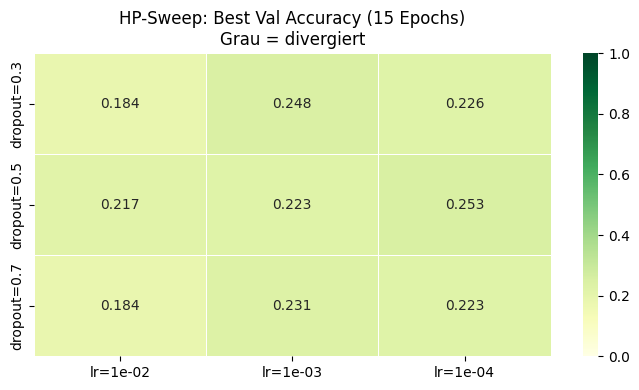

In [8]:
heatmap_data = np.zeros((len(DROPOUT_VALUES), len(LR_VALUES)))
mask_diverged = np.zeros_like(heatmap_data, dtype=bool)

for j, lr in enumerate(LR_VALUES):
    for i, dropout in enumerate(DROPOUT_VALUES):
        h = results[(lr, dropout)]
        heatmap_data[i, j] = h["best_val_acc"]
        mask_diverged[i, j] = h["diverged"]

fig, ax = plt.subplots(figsize=(7, 4))

# Divergierte Zellen grau
grey_map = plt.cm.Greys(np.ones_like(heatmap_data) * 0.3)  # type: ignore[attr-defined]
ax.imshow(
    np.where(mask_diverged, 0.0, np.nan),
    cmap="Greys", vmin=0, vmax=1,
    aspect="auto",
)

sns.heatmap(
    pd.DataFrame(
        heatmap_data,
        index=[f"dropout={d}" for d in DROPOUT_VALUES],
        columns=[f"lr={lr:.0e}" for lr in LR_VALUES],
    ),
    annot=True, fmt=".3f",
    cmap="YlGn", vmin=0.0, vmax=1.0,
    mask=mask_diverged,
    ax=ax,
    linewidths=0.5,
)

# Divergierte Zellen beschriften
for i in range(len(DROPOUT_VALUES)):
    for j in range(len(LR_VALUES)):
        if mask_diverged[i, j]:
            ax.text(j + 0.5, i + 0.5, "DIV", ha="center", va="center",
                    fontsize=10, color="red", fontweight="bold")

ax.set_title("HP-Sweep: Best Val Accuracy (15 Epochs)\nGrau = divergiert", fontsize=12)
plt.tight_layout()
plt.show()

## Visualisierung 2: Loss- und Accuracy-Kurven (3×3 Grid)

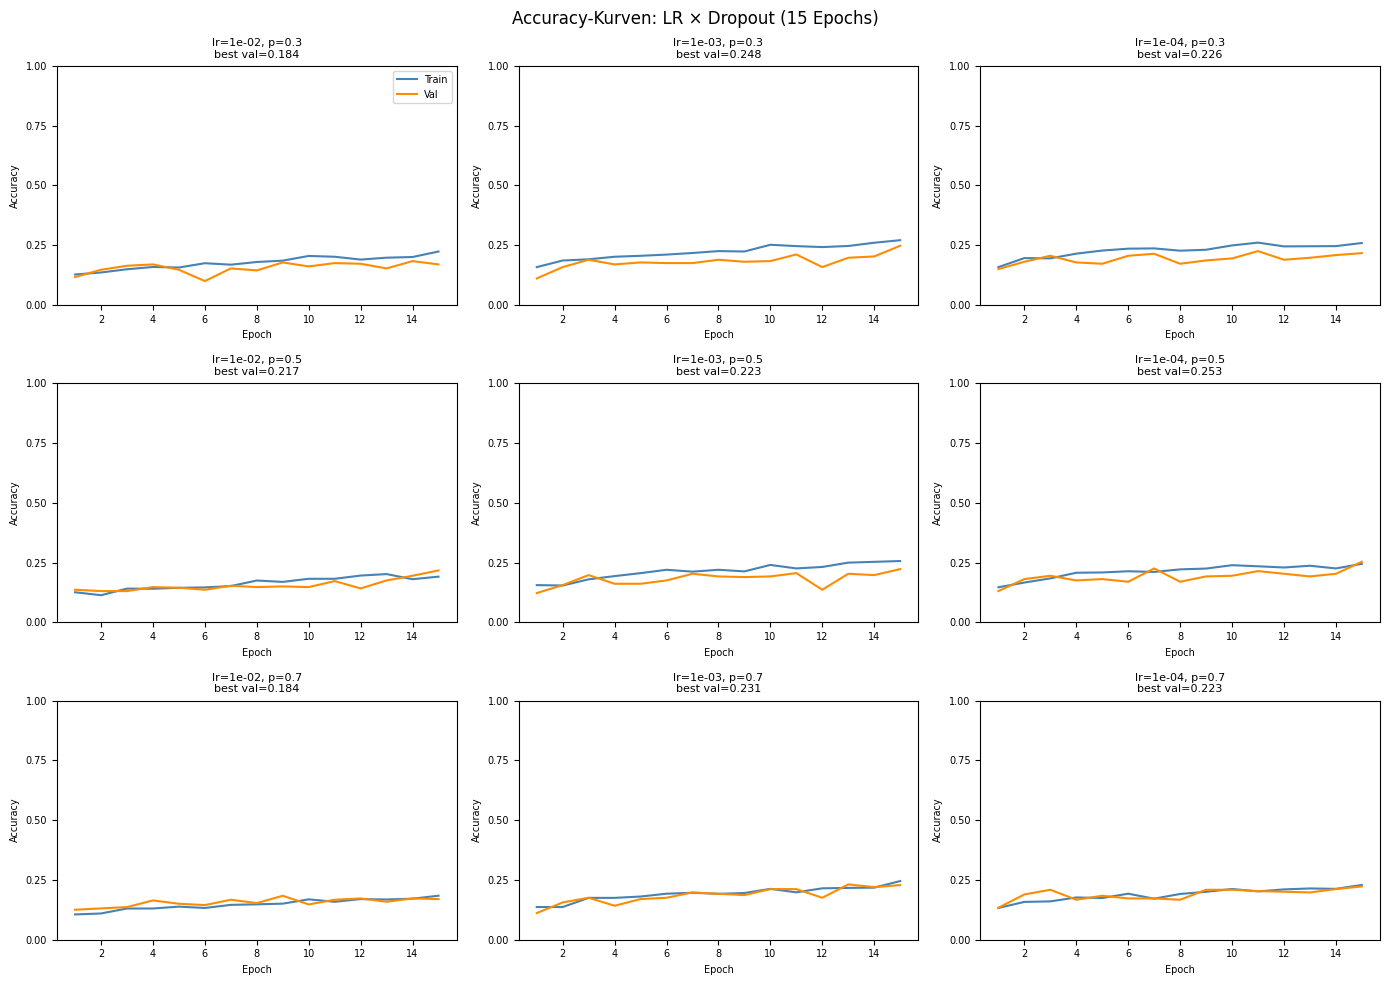

In [9]:
fig, axes = plt.subplots(
    len(DROPOUT_VALUES), len(LR_VALUES),
    figsize=(14, 10),
    squeeze=False,
)

for i, dropout in enumerate(DROPOUT_VALUES):
    for j, lr in enumerate(LR_VALUES):
        ax = axes[i][j]
        h  = results[(lr, dropout)]
        epochs_run = len(h["val_acc_hist"])

        if h["diverged"] and epochs_run == 0:
            ax.text(0.5, 0.5, "DIVERGIERT\n(kein Ergebnis)",
                    ha="center", va="center", transform=ax.transAxes,
                    color="red", fontsize=9)
        else:
            ep = range(1, epochs_run + 1)
            ax.plot(ep, h["train_acc_hist"], label="Train", color="steelblue")
            ax.plot(ep, h["val_acc_hist"],   label="Val",   color="darkorange")
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
            if h["diverged"]:
                ax.set_title(f"lr={lr:.0e}, p={dropout} [DIV]",
                             fontsize=8, color="red")
            else:
                best = h["best_val_acc"]
                ax.set_title(f"lr={lr:.0e}, p={dropout}\nbest val={best:.3f}",
                             fontsize=8)
            if i == 0 and j == 0:
                ax.legend(fontsize=7)

        ax.set_xlabel("Epoch", fontsize=7)
        ax.set_ylabel("Accuracy", fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle("Accuracy-Kurven: LR × Dropout (15 Epochs)", fontsize=12)
plt.tight_layout()
plt.show()

## Beste Konfiguration → für Notebook 04 verwenden

In [10]:
best_lr, best_dropout = max(
    ((lr, d) for (lr, d) in results if not results[(lr, d)]["diverged"]),
    key=lambda k: results[k]["best_val_acc"],
)

print("══════════════════════════════════════")
print(f"  Beste Konfiguration:")
print(f"    Learning Rate : {best_lr:.0e}")
print(f"    Dropout       : {best_dropout}")
print(f"    Best Val Acc  : {results[(best_lr, best_dropout)]['best_val_acc']:.3f}")
print("══════════════════════════════════════")
print()
print("→ Diese Werte in notebooks/04_scratch_cnn.ipynb als BEST_LR / BEST_DROPOUT eintragen.")

══════════════════════════════════════
  Beste Konfiguration:
    Learning Rate : 1e-04
    Dropout       : 0.5
    Best Val Acc  : 0.253
══════════════════════════════════════

→ Diese Werte in notebooks/04_scratch_cnn.ipynb als BEST_LR / BEST_DROPOUT eintragen.
